# 2. Data Exploration & Quality Analysis

## 2.1 Dataset Import & Initial Inspection
In this section, we load the raw dataset and inspect its structure, data types, and initial records to verify data integrity.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('online_shoppers_intention.csv')

# Display dataset dimensions and first 5 rows
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Dimensions: 12330 rows, 18 columns



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2.2 Data Structure & Quality Audit
We evaluate column data types, verify missing values, detect duplicated session records, and check target variable distribution to determine necessary preprocessing steps.

In [17]:
# Check data summary, missing values, and duplicate rows
print(f"Total Duplicate Rows: {df.duplicated().sum()}\n")

print("Missing Values per Column:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values detected across all columns!\n")

# Target Distribution (Revenue)
revenue_summary = pd.DataFrame({
    'Count': df['Revenue'].value_counts(),
    'Percentage (%)': (df['Revenue'].value_counts(normalize=True) * 100).round(2)
})
print("--- Target Distribution (Revenue) ---")
print(revenue_summary)

Total Duplicate Rows: 125

Missing Values per Column:
No missing values detected across all columns!

--- Target Distribution (Revenue) ---
         Count  Percentage (%)
Revenue                       
False    10422           84.53
True      1908           15.47


## 2.3 Visualizing Target Class Imbalance
We plot the distribution of the target variable `Revenue` to visually demonstrate the ratio between converting and non-converting user sessions.

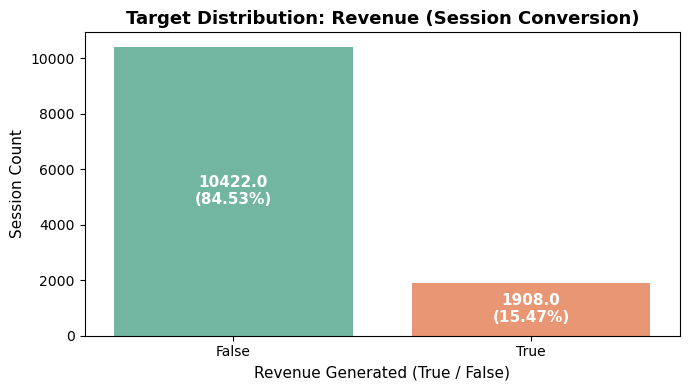

In [18]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='Revenue', hue='Revenue', data=df, palette='Set2', legend=False)
plt.title('Target Distribution: Revenue (Session Conversion)', fontsize=13, fontweight='bold')
plt.xlabel('Revenue Generated (True / False)', fontsize=11)
plt.ylabel('Session Count', fontsize=11)

# Annotate count and percentage inside each bar
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{(100 * height / total):.2f}%'
    ax.annotate(f'{height}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 2.4 Statistical Summary of Continuous Numerical Features
We evaluate the central tendencies, spread, and extremes across user browsing duration, bounce rates, exit rates, and page values to spot skewness and outliers.

In [19]:
# Select continuous session metrics
num_cols = [
    'Administrative_Duration', 'Informational_Duration', 
    'ProductRelated_Duration', 'BounceRates', 'ExitRates', 
    'PageValues', 'SpecialDay'
]

# Transpose output for readability and display key metrics
num_summary = df[num_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]
num_summary.columns = ['Mean', 'Std Dev', 'Min', 'Median (50%)', 'Max']
display(num_summary)

,Mean,Std Dev,Min,Median (50%),Max
Administrative_Duration,80.818611,176.779107,0.0,7.500000,3398.750000
Informational_Duration,34.472398,140.749294,0.0,0.000000,2549.375000
ProductRelated_Duration,1194.746220,1913.669288,0.0,598.936905,63973.522230
BounceRates,0.022191,0.048488,0.0,0.003112,0.200000
ExitRates,0.043073,0.048597,0.0,0.025156,0.200000
PageValues,5.889258,18.568437,0.0,0.000000,361.763742
SpecialDay,0.061427,0.198917,0.0,0.000000,1.000000


## 2.5 Continuous Feature Distributions vs. Revenue
We plot boxplots for key continuous metrics (`PageValues`, `ExitRates`, `ProductRelated_Duration`) segmented by conversion status to observe feature separation.

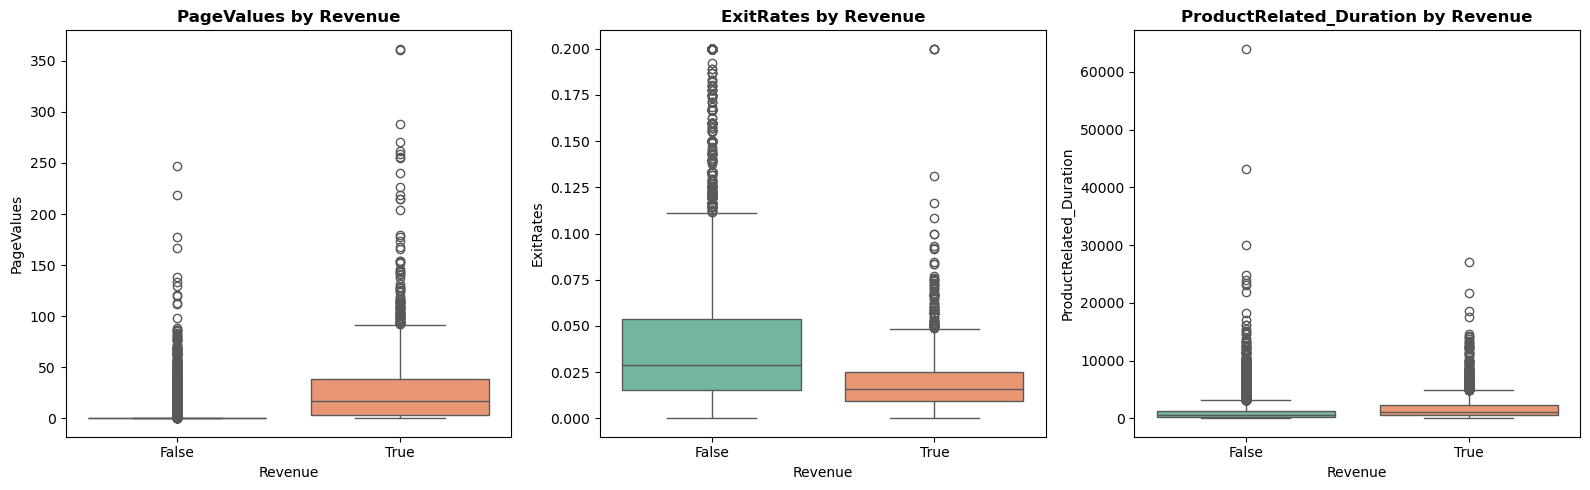

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# PageValues vs Revenue
sns.boxplot(x='Revenue', y='PageValues', hue='Revenue', data=df, ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('PageValues by Revenue', fontweight='bold')

# ExitRates vs Revenue
sns.boxplot(x='Revenue', y='ExitRates', hue='Revenue', data=df, ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('ExitRates by Revenue', fontweight='bold')

# ProductRelated_Duration vs Revenue
sns.boxplot(x='Revenue', y='ProductRelated_Duration', hue='Revenue', data=df, ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('ProductRelated_Duration by Revenue', fontweight='bold')

plt.tight_layout()
plt.show()

## 2.6 Categorical Feature Distributions vs. Revenue
We analyze conversion rates across traffic months (`Month`) and visitor classifications (`VisitorType`) to evaluate seasonality and visitor loyalty impact.

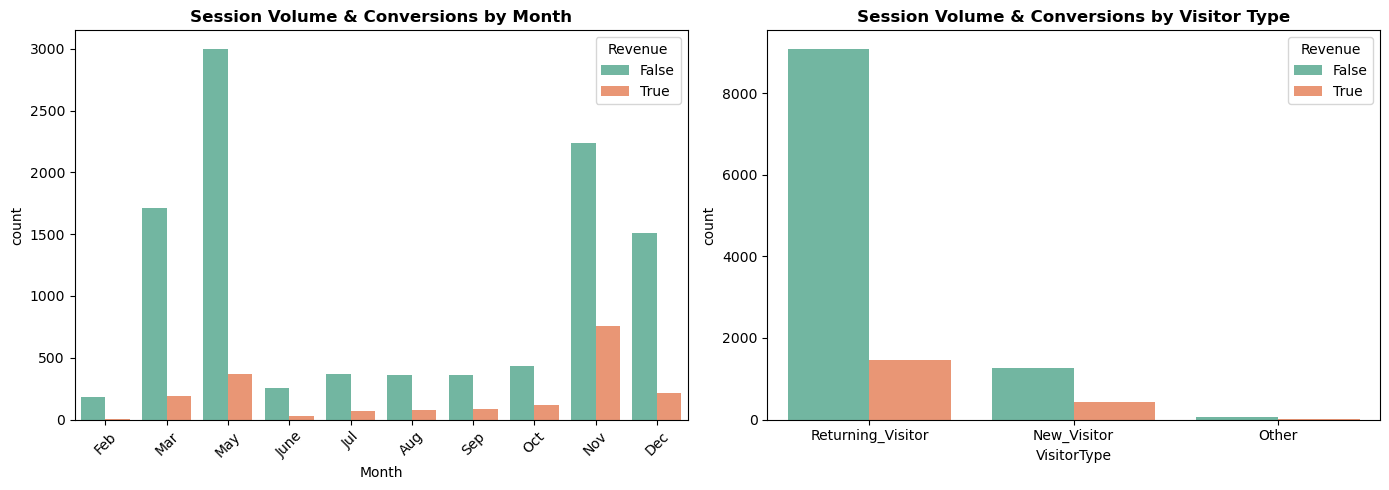

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conversion by Month
sns.countplot(x='Month', hue='Revenue', data=df, ax=axes[0], palette='Set2', 
              order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].set_title('Session Volume & Conversions by Month', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Conversion by VisitorType
sns.countplot(x='VisitorType', hue='Revenue', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Session Volume & Conversions by Visitor Type', fontweight='bold')

plt.tight_layout()
plt.show()

## 2.7 Correlation Analysis & Multicollinearity Inspection
We generate a Pearson correlation heatmap across continuous features to identify highly collinear predictors that may cause redundancy during model training.

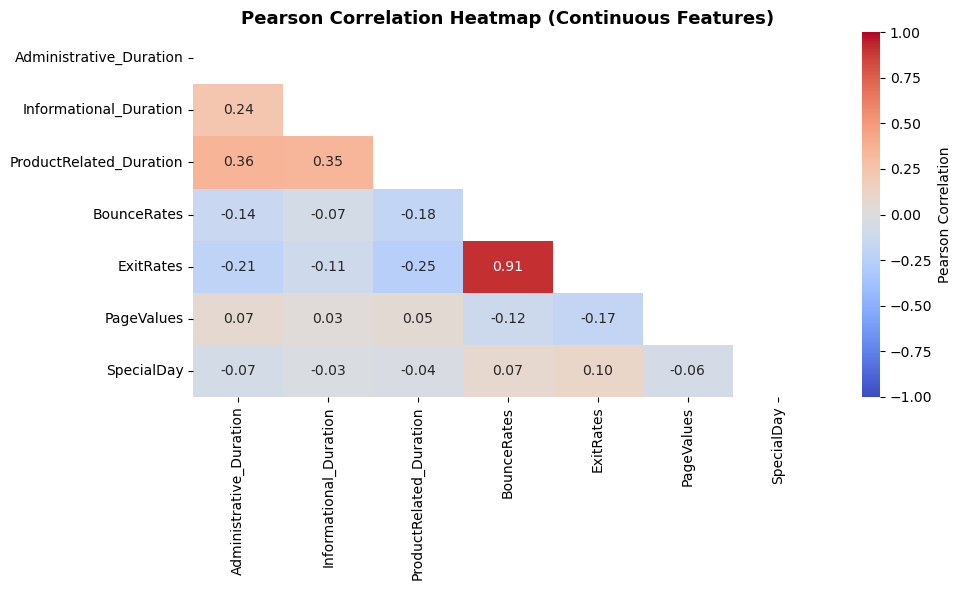

In [22]:
plt.figure(figsize=(10, 6))
correlation_matrix = df[num_cols].corr()

# Mask upper triangle for cleaner layout
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Pearson Correlation Heatmap (Continuous Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Data Preprocessing & Cleaning

## 3.1 Removing Duplicate Observations
To prevent model bias toward repeated session logs, we drop the 125 duplicate rows identified during our initial quality audit.

In [23]:
# Record initial count
initial_count = len(df)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Confirm removal
clean_count = len(df)
print(f"Initial Row Count: {initial_count}")
print(f"Cleaned Row Count: {clean_count}")
print(f"Successfully Removed: {initial_count - clean_count} duplicate rows.")

Initial Row Count: 12330
Cleaned Row Count: 12205
Successfully Removed: 125 duplicate rows.


## 3.2 Categorical Feature Encoding
We convert boolean features into binary integers (0 and 1) and apply One-Hot Encoding with first-category dropping to `Month` and `VisitorType` to avoid dummy variable redundancy.

In [24]:
# Create a copy for preprocessing
df_clean = df.copy()

# Map boolean columns to binary integers
df_clean['Weekend'] = df_clean['Weekend'].astype(int)
df_clean['Revenue'] = df_clean['Revenue'].astype(int)

# One-Hot Encode nominal categorical attributes
df_encoded = pd.get_dummies(df_clean, columns=['Month', 'VisitorType'], drop_first=True, dtype=int)

print(f"Preprocessed Dataset Shape: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns\n")
df_encoded.head()

Preprocessed Dataset Shape: 12205 rows, 27 columns



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


## 3.3 Stratified Train-Test Dataset Splitting
We split the feature matrix and target vector into an 80/20 train-test split using stratification to preserve the imbalanced class ratio across training and evaluation sets.

In [25]:
from sklearn.model_selection import train_test_split

# Separate feature matrix (X) and target vector (y)
X = df_encoded.drop(columns=['Revenue'])
y = df_encoded['Revenue']

# Execute stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Features Matrix: {X_train.shape}")
print(f"Testing Features Matrix:  {X_test.shape}")
print(f"Train Target Distribution:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"Test Target Distribution:\n{y_test.value_counts(normalize=True).round(4)}")

Training Features Matrix: (9764, 26)
Testing Features Matrix:  (2441, 26)
Train Target Distribution:
Revenue
0    0.8437
1    0.1563
Name: proportion, dtype: float64
Test Target Distribution:
Revenue
0    0.8435
1    0.1565
Name: proportion, dtype: float64


## 3.4 Feature Scaling (StandardScaler)
We standardize continuous numerical attributes to mean 0 and variance 1. The scaler is fit strictly on training features and applied to testing features to prevent data leakage.

In [26]:
from sklearn.preprocessing import StandardScaler

# Continuous feature subset requiring standardization
scale_cols = [
    'Administrative', 'Administrative_Duration', 
    'Informational', 'Informational_Duration', 
    'ProductRelated', 'ProductRelated_Duration', 
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

# Initialize scaler and fit strictly on X_train
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("StandardScaler successfully fit on X_train and applied to X_train and X_test!\n")
X_train_scaled[scale_cols].head()

StandardScaler successfully fit on X_train and applied to X_train and X_test!



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
7556,1.689206,0.676238,0.381750,-0.243015,0.220868,-0.080395,-0.448703,-0.800192,1.665596,-0.311837
11924,-0.699498,-0.458067,-0.397879,-0.243015,-0.046900,-0.158842,-0.448703,-0.739774,1.495448,-0.311837
3306,-0.699498,-0.458067,-0.397879,-0.243015,-0.426237,-0.408089,-0.448703,-0.287446,-0.315264,3.689185
207,-0.102322,-0.235218,-0.397879,-0.243015,-0.604748,-0.336795,-0.448703,-0.279507,-0.315264,-0.311837
4460,-0.699498,-0.458067,-0.397879,-0.243015,-0.359295,0.203501,-0.448703,-0.609743,-0.315264,-0.311837


# 4. Model Training & Imbalance Handling

## 4.1 Baseline Model Benchmarking (Logistic Regression vs. Random Forest)
We train Logistic Regression and Random Forest classifiers on the scaled training dataset. To address class imbalance, we enable `class_weight='balanced'` and evaluate performance on the held-out test set using ROC-AUC, Recall, and F1-Score.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Initialize baseline models with balanced class weights
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train models
log_reg.fit(X_train_scaled, y_train)
rf_clf.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

# Display evaluation summaries
print("=== LOGISTIC REGRESSION PERFORMANCE ===")
print(classification_report(y_test, y_pred_log, digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_log):.4f}\n")

print("=== RANDOM FOREST PERFORMANCE ===")
print(classification_report(y_test, y_pred_rf, digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== LOGISTIC REGRESSION PERFORMANCE ===
              precision    recall  f1-score   support

           0     0.9559    0.8635    0.9074      2059
           1     0.5164    0.7853    0.6231       382

    accuracy                         0.8513      2441
   macro avg     0.7361    0.8244    0.7652      2441
weighted avg     0.8871    0.8513    0.8629      2441

ROC-AUC Score: 0.9109

=== RANDOM FOREST PERFORMANCE ===
              precision    recall  f1-score   support

           0     0.9480    0.9213    0.9345      2059
           1     0.6318    0.7277    0.6764       382

    accuracy                         0.8910      2441
   macro avg     0.7899    0.8245    0.8054      2441
weighted avg     0.8985    0.8910    0.8941      2441

ROC-AUC Score: 0.9253


## 4.2 Confusion Matrix Benchmarking
We visualize confusion matrices for both baseline models on the test set (2,441 sessions) to evaluate classification errors.

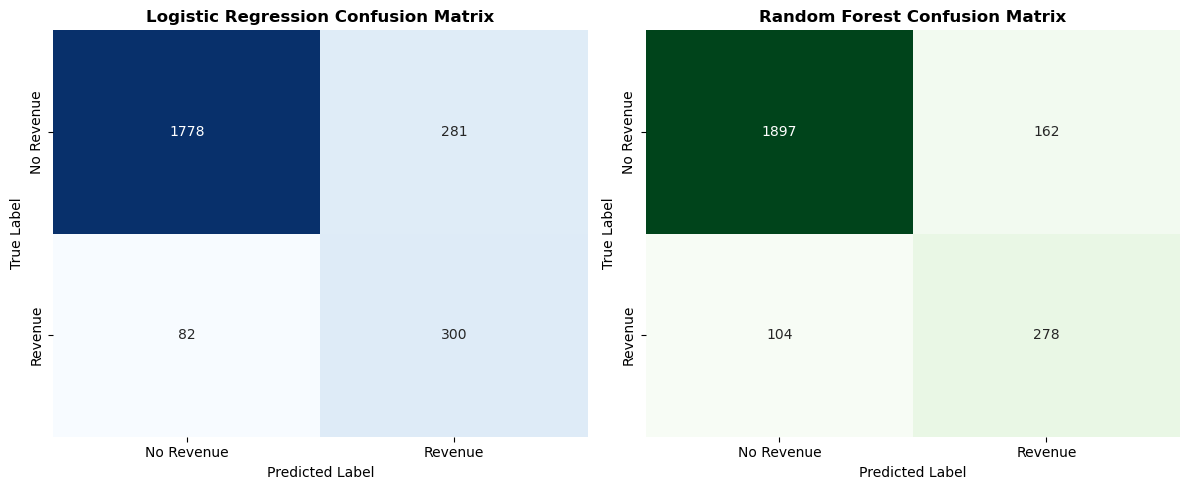

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['No Revenue', 'Revenue'], yticklabels=['No Revenue', 'Revenue'])
axes[0].set_title('Logistic Regression Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['No Revenue', 'Revenue'], yticklabels=['No Revenue', 'Revenue'])
axes[1].set_title('Random Forest Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## 4.3 ROC-AUC Performance Curves
We plot ROC curves for Logistic Regression and Random Forest to evaluate discrimination performance across varying decision thresholds.

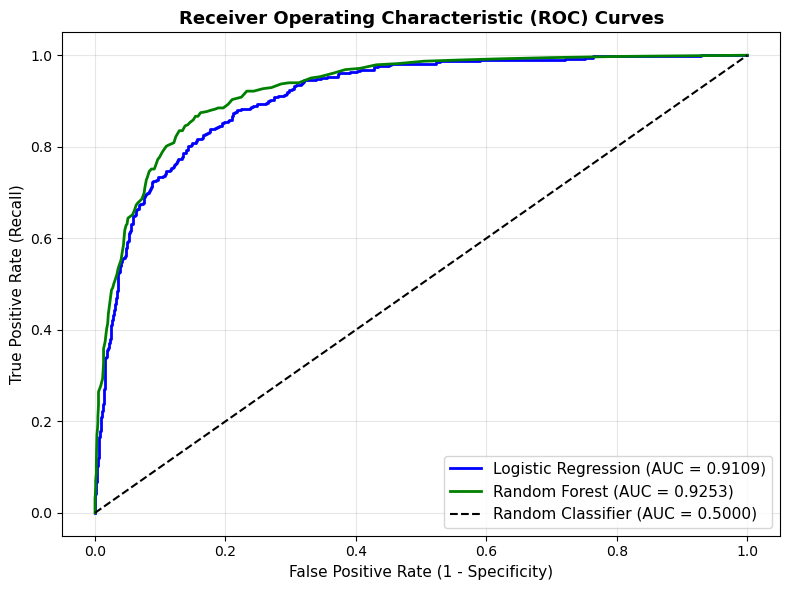

In [29]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.4f})', color='blue', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5000)')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.4 Target Imbalance Handling via SMOTE
We apply Synthetic Minority Over-sampling Technique (SMOTE) to synthetically balance positive and negative conversion classes in the training set, evaluating its impact on Random Forest recall and precision.

In [31]:
from imblearn.over_sampling import SMOTE

# Initialize and apply SMOTE strictly to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("--- Class Distribution Before & After SMOTE ---")
print(f"Original Training Target Count:\n{y_train.value_counts().to_dict()}")
print(f"SMOTE Resampled Training Count:\n{y_train_smote.value_counts().to_dict()}\n")

# Train Random Forest on SMOTE-balanced data
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

# Evaluate on test set
y_pred_rf_smote = rf_smote.predict(X_test_scaled)
y_proba_rf_smote = rf_smote.predict_proba(X_test_scaled)[:, 1]

print("=== RANDOM FOREST WITH SMOTE PERFORMANCE ===")
print(classification_report(y_test, y_pred_rf_smote, digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf_smote):.4f}")

--- Class Distribution Before & After SMOTE ---
Original Training Target Count:
{0: 8238, 1: 1526}
SMOTE Resampled Training Count:
{1: 8238, 0: 8238}

=== RANDOM FOREST WITH SMOTE PERFORMANCE ===
              precision    recall  f1-score   support

           0     0.9468    0.9252    0.9359      2059
           1     0.6410    0.7199    0.6782       382

    accuracy                         0.8931      2441
   macro avg     0.7939    0.8226    0.8070      2441
weighted avg     0.8990    0.8931    0.8956      2441

ROC-AUC Score: 0.9249


# 5. Model Interpretability & Feature Importance

## 5.1 Random Forest Feature Importance Analysis
We extract Gini feature importances from our Random Forest model to identify the primary predictors of e-commerce session conversions.

/tmp/ipykernel_14951/2070822087.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


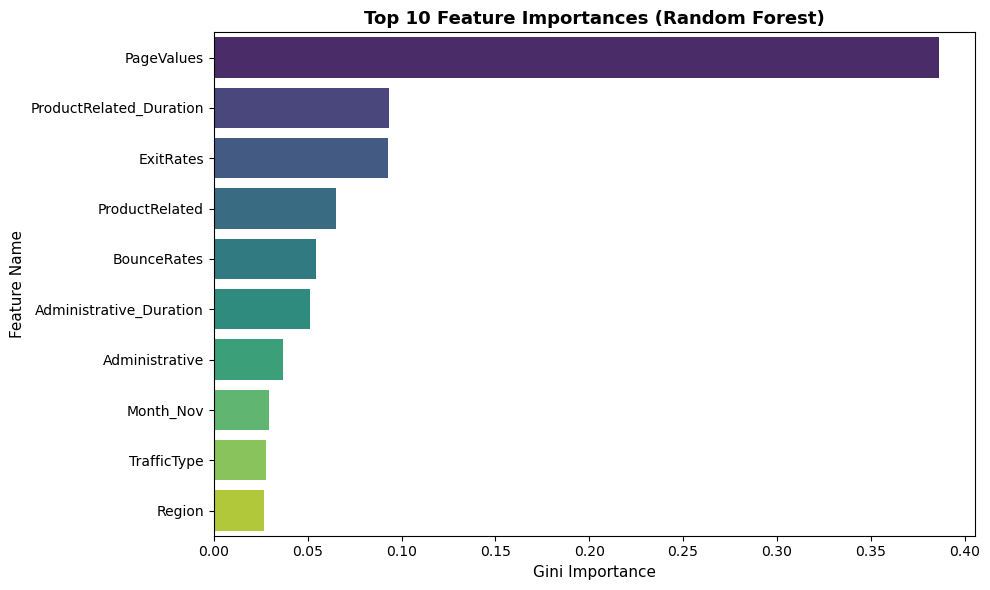

In [32]:
# Extract feature importances from Random Forest model
importances = rf_clf.feature_importances_
feature_names = X_train.columns

# Build structured dataframe
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 10 most influential features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Gini Importance', fontsize=11)
plt.ylabel('Feature Name', fontsize=11)
plt.tight_layout()
plt.show()

# 6. Model Persistence & Deployment Setup

## 6.1 Exporting Trained Artifacts
We serialize the final Random Forest classifier (`rf_clf`) and feature scaler (`scaler`) to disk for future inference pipelines.

In [33]:
import joblib

# Export model and scaler artifacts
joblib.dump(rf_clf, 'random_forest_model.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')

print("Model and Scaler successfully saved to project directory:")
print(" - random_forest_model.pkl")
print(" - standard_scaler.pkl")

Model and Scaler successfully saved to project directory:
 - random_forest_model.pkl
 - standard_scaler.pkl
